In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import json
import datetime
import os
import time
import pytz
import matplotlib.pyplot as plt
import scipy
from scipy.stats import norm

In [4]:
def get_logrets_daily(symbol, start_date, end_date):
    eastern = pytz.timezone('US/Eastern')
    stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
    stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
    stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
    stockprices['close_prev'] = stockprices['Close'].shift(1)
    stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
    stockprices = stockprices[(stockprices['Date']>=eastern.localize(start_date)) & (stockprices['Date']<=eastern.localize(end_date))]
    return stockprices['log_ret'].dropna()

In [52]:
def compare_with_normal(data, n_bins):
    mean = data.mean()
    std = data.std()
    normalised_data = (data - mean)/std
    normal_samples = np.random.randn(len(data))

    # Plot the histograms and the PDF.
    plt.figure(figsize=(10, 6))

    # Plot the histogram of the given data.
    plt.hist(normalised_data, bins=n_bins, density=True, alpha=0.5, color='g', label='Log returns')

    # Plot the histogram of the standard normal sample.
    plt.hist(normal_samples, bins=n_bins, density=True, alpha=0.5, color='b', label='Standard Normal Sample')

    # Plot the PDF of the standard normal distribution.
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, 0, 1)
    plt.plot(x, p, 'k', linewidth=2, label='Standard Normal PDF')

    # Add titles and labels.
    plt.title('Histograms and Standard Normal PDF')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()

In [27]:
def remove_outliers(data, n_sigma):
    mean = data.mean()
    std = data.std()
    return data[(data<(mean+(n_sigma*std))) & (data>(mean-(n_sigma*std)))]

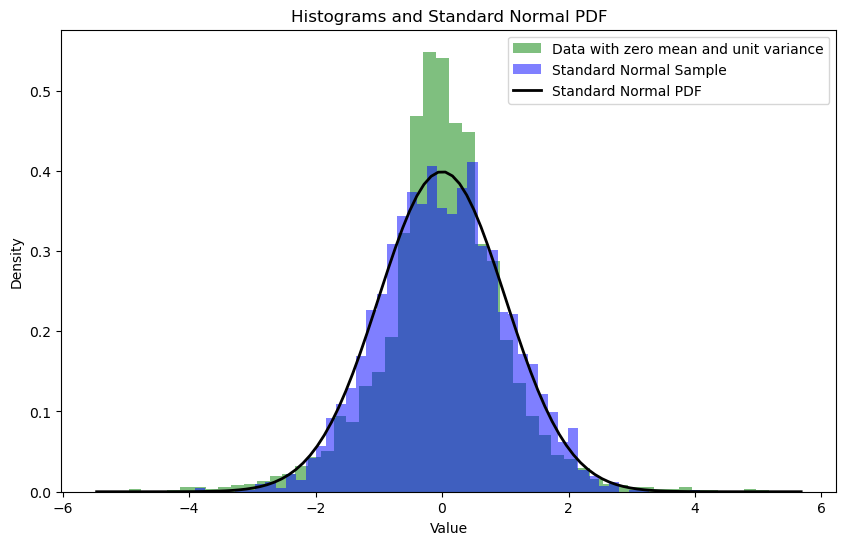

In [28]:
symbol='AAPL'
start_date = datetime.datetime(2014,5,20, 0,0,0)
end_date = datetime.datetime(2024,5,20, 0,0,0)
compare_with_normal(remove_outliers(get_logrets_daily(symbol, start_date, end_date) , 5), 50)

In [47]:
symbols_list = ['MO', 'K', 'COST', 'PEG', 'RL', 'T', 'NVDA', 'SHW', 'WELL', 'META']
weights = np.array([0.28762189, 0.27149217, 0.08911822, 0.07566661, 0.03032778,
        0.08159039, 0.03395307, 0.04588665, 0.05491741, 0.02942581])

In [49]:
div_portfolio_returns = pd.read_csv('divportfolioreturns.csv')
returns_matrix = div_portfolio_returns.to_numpy()
print(returns_matrix.shape)
print(len(returns_matrix@weights))

(264, 10)
264


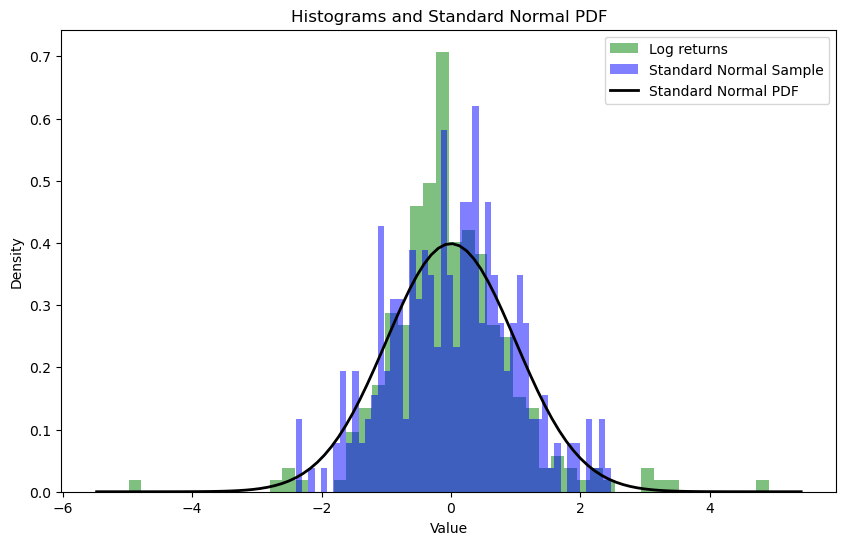

In [59]:
compare_with_normal(remove_outliers(np.log((returns_matrix+1)@weights), 5), 50)

In [60]:
def normal_test(data):
    mean = data.mean()
    std = data.std()
    normalised_data = (data - mean)/std
    res = scipy.stats.normaltest(normalised_data)
    print(res.pvalue)

In [61]:
normal_test(np.log((returns_matrix+1)@weights))

6.233496394519091e-10


In [65]:
eastern = pytz.timezone('US/Eastern')

def get_daily_rets(symbols_list, start_date, end_date):
    df = pd.DataFrame()
    for item in symbols_list:
        stockprices = pd.read_csv(f'StockPriceData/{item}.csv')
        stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
        stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
        stockprices['close_prev'] = stockprices['Close'].shift(1)
        stockprices = stockprices[(stockprices['Date']>=eastern.localize(start_date)) & (stockprices['Date']<=eastern.localize(end_date))]
        stockprices[f'{item}'] = stockprices['Close']/stockprices['close_prev'] - 1
        if df.empty:
            df = stockprices[['Date', f'{item}']]
        else:
            df = pd.merge(df, stockprices[['Date', f'{item}']], how='outer', on='Date')

    return df

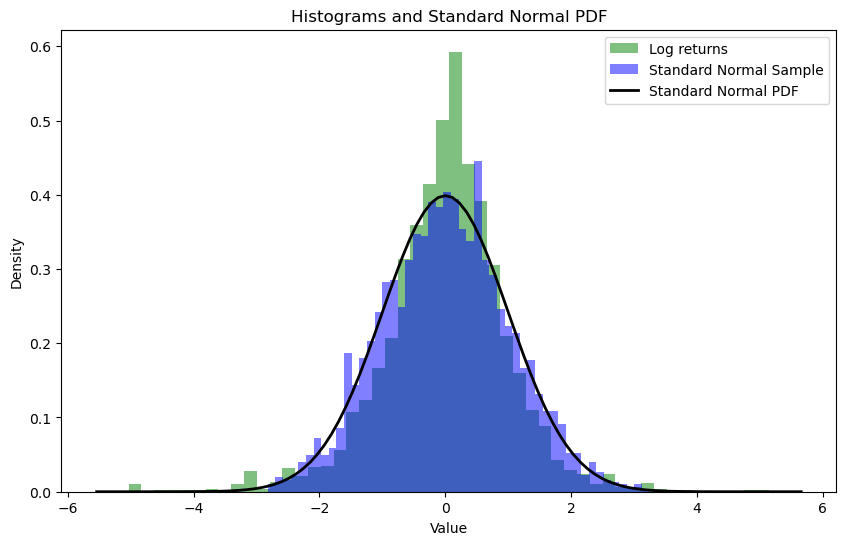

In [68]:
start_date = datetime.datetime(2014,5,20, 0,0,0)
end_date = datetime.datetime(2024,5,20, 0,0,0)

returns_matrix = get_daily_rets(symbols_list, start_date, end_date).drop(columns=['Date']).to_numpy()
compare_with_normal(remove_outliers(np.log((returns_matrix+1)@weights), 5), 50)

In [44]:
div_portfolio_returns

,MO,K,COST,PEG,RL,T,NVDA,SHW,WELL,META
0,0.000228,-0.015209,-0.000941,0.010567,-0.000122,0.001776,-0.038900,0.012450,-0.009656,0.020969
1,0.003651,0.075465,0.014151,0.003008,0.007945,-0.005910,0.033429,0.003692,0.018228,0.005669
2,-0.008868,-0.012565,0.015646,0.006141,0.010429,0.001784,0.034632,0.022466,-0.002810,0.023275
3,-0.002294,-0.007767,0.016870,0.012633,0.000120,0.008308,0.037741,0.011854,0.010124,0.030357
4,0.008278,0.026649,0.019644,0.008971,0.000360,0.005297,-0.017213,0.011937,0.007026,0.005497
...,...,...,...,...,...,...,...,...,...,...
259,-0.002479,-0.003775,-0.007497,-0.003866,-0.000890,-0.000378,0.041638,-0.013117,-0.008367,0.005076
260,0.030712,0.004034,0.019092,0.014879,-0.001669,0.033661,-0.003768,0.028688,0.024338,-0.023477
261,0.014296,0.002070,0.015201,0.010836,0.020178,0.014270,0.004227,0.007902,0.012458,-0.005498
262,0.009849,0.001215,0.008296,0.006054,0.011438,0.010823,0.001256,-0.004154,0.012977,0.000140


7016     4.539150
6538     4.476077
7699     4.320583
5953     4.316476
12043    4.275100
           ...   
2730    -4.694839
10938   -4.711208
7674    -4.720988
6658    -4.789765
12055   -4.870750
Name: log_ret, Length: 13321, dtype: float64
[-3.95220072 -3.56504545 -3.56410299 ...  3.21137601  3.26629935
  3.30843415]
3.537214265472076e-148


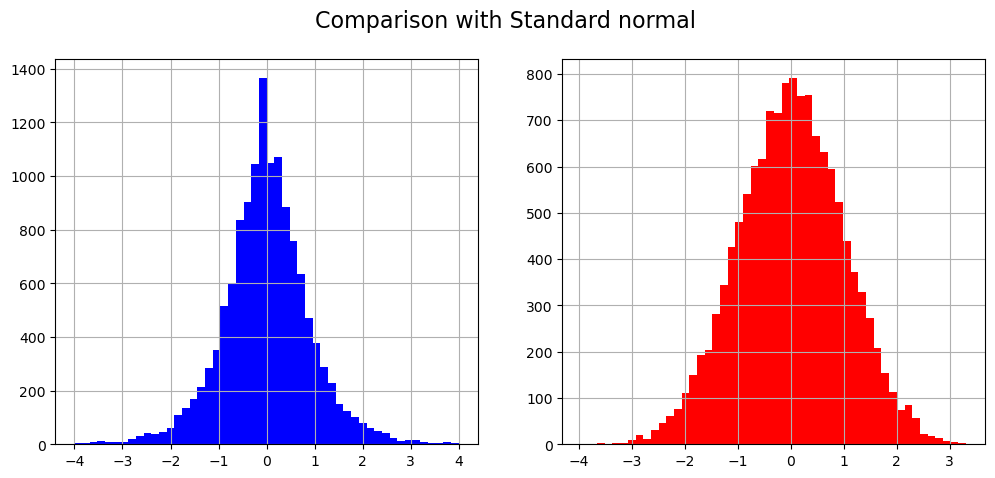

In [82]:
for symbol in symbols:
    stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
    stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
    stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
    stockprices['close_prev'] = stockprices['Close'].shift(1)
    stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
    mean = stockprices['log_ret'].mean()
    std = stockprices['log_ret'].std()
    logret_normalised = (stockprices['log_ret'].dropna() - mean)/std
    logret_filtered = logret_normalised[(logret_normalised<5)&(logret_normalised>(-5))]
    gaussian = np.random.standard_normal(len(logret_filtered))
    #plt.hist(stockprices['log_ret'], bins=100)
    #plt.show()
    print(logret_filtered.sort_values(ascending=False))
    gaussian.sort()
    print(gaussian)
    res = scipy.stats.normaltest(logret_filtered)
    print(res.pvalue)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Comparison with Standard normal', fontsize=16)
    ax1.hist(logret_filtered, bins=50, color='b', range=(-4,4))
    ax2.hist(gaussian, bins=50, color='r')
    # ax1.set_title('First Plot')
    # ax1.set_xlabel('x-axis')
    # ax1.set_ylabel('y-axis')
    ax1.grid(True) # Add a grid for better readability
    ax2.grid(True) # Add a grid
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




In [36]:
def get_logrets_minute(symbol, start, end):
    stockprices = yf.download(symbol, interval='1m', start=start, end=end)
    stockprices['log_ret'] = np.log(stockprices['Close'][symbol]/(stockprices['Close'][symbol].shift(1)))
    return stockprices['log_ret'].dropna()


In [37]:
start = datetime.datetime(2025,6,2, 0,0,0)
end = datetime.datetime(2025,6,9, 0,0,0)

get_logrets_minute('LLY', start, end)

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_4743/1858241673.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockprices = yf.download(symbol, interval='1m', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Datetime
2025-06-02 13:31:00+00:00   -0.000109
2025-06-02 13:33:00+00:00    0.005866
2025-06-02 13:34:00+00:00    0.001637
2025-06-02 13:35:00+00:00   -0.002395
2025-06-02 13:36:00+00:00    0.001286
                               ...   
2025-06-06 19:55:00+00:00    0.000429
2025-06-06 19:56:00+00:00    0.000545
2025-06-06 19:57:00+00:00    0.000078
2025-06-06 19:58:00+00:00   -0.000857
2025-06-06 19:59:00+00:00    0.000091
Name: log_ret, Length: 1889, dtype: float64

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_4743/1858241673.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockprices = yf.download(symbol, interval='1m', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


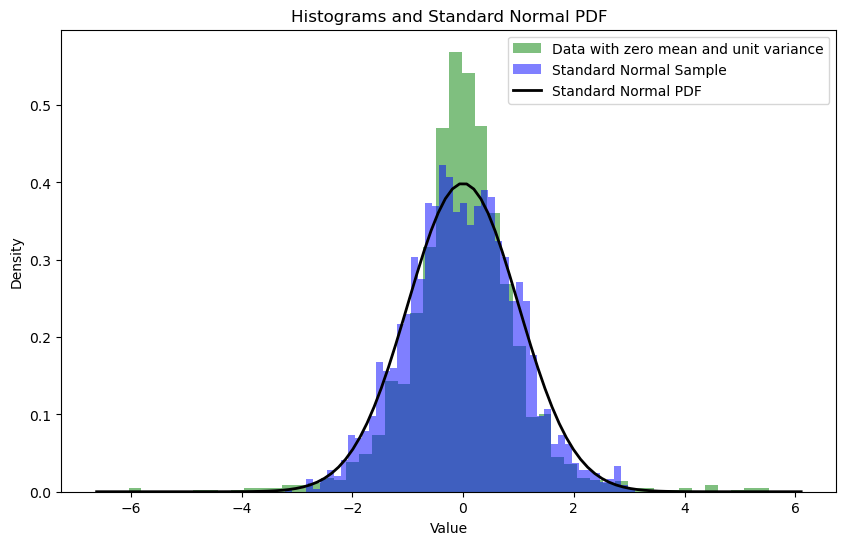

In [38]:
compare_with_normal(remove_outliers(get_logrets_minute(symbol, start, end) , 5), 50)

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_4743/1858241673.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockprices = yf.download(symbol, interval='1m', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


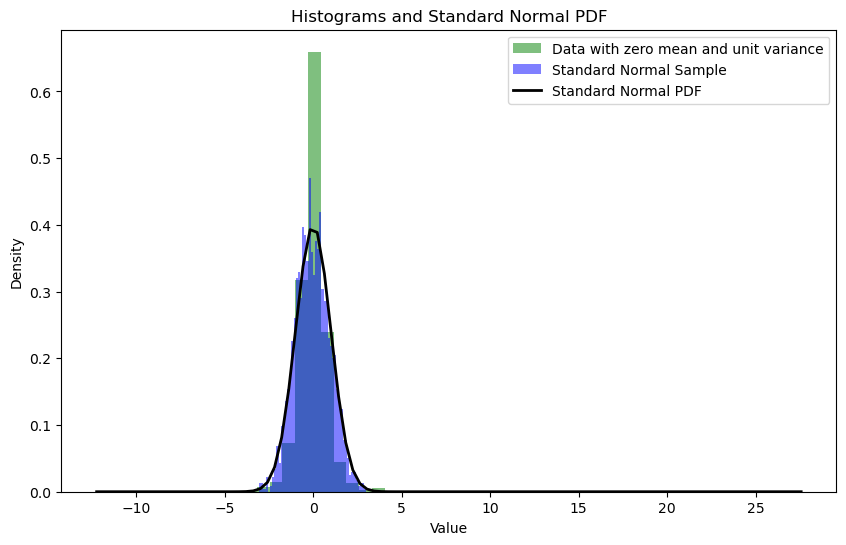

In [39]:
compare_with_normal(get_logrets_minute(symbol, start, end) , 50)